In [1]:
import pandas as pd
import yfinance as yf

# Define the ticker symbol for crude oil
symbol = "CL=F"  # Adjust as needed for specific contracts

# Define the date range for the historical data
start_date = "2010-01-01"
end_date = "2023-07-31"

# Download the historical data from Yahoo Finance
data = yf.download(symbol, start=start_date, end=end_date)

# Save the data as a CSV file
data.to_csv("crude_oil_prices.csv")


# Read the CSV file
data = pd.read_csv("crude_oil_prices.csv")

# Display the first few rows of the data
print(data.head())

[*********************100%***********************]  1 of 1 completed
         Date       Open       High        Low      Close  Adj Close  Volume
0  2010-01-04  79.629997  81.680000  79.629997  81.510002  81.510002  263542
1  2010-01-05  81.629997  82.000000  80.949997  81.769997  81.769997  258887
2  2010-01-06  81.430000  83.519997  80.849998  83.180000  83.180000  370059
3  2010-01-07  83.199997  83.360001  82.260002  82.660004  82.660004  246632
4  2010-01-08  82.650002  83.470001  81.800003  82.750000  82.750000  310377


In [2]:
data.describe()

,Open,High,Low,Close,Adj Close,Volume
count,3413.000000,3413.000000,3413.000000,3413.000000,3413.000000,3.413000e+03
mean,71.455412,72.507445,70.293425,71.431702,71.431702,4.113035e+05
std,22.253608,22.375569,22.116452,22.289681,22.289681,2.087380e+05
min,-14.000000,13.690000,-40.320000,-37.630001,-37.630001,0.000000e+00
25%,52.180000,52.990002,51.250000,52.220001,52.220001,2.659300e+05
50%,71.470001,72.330002,70.260002,71.339996,71.339996,3.567220e+05
75%,91.629997,92.849998,90.440002,91.660004,91.660004,5.336820e+05
max,124.660004,130.500000,120.790001,123.699997,123.699997,2.288230e+06


In [3]:
df=data[['Date','Close']]
df.index=pd.to_datetime(df.Date)
df.drop(['Date'],axis=1,inplace=True)
df.head()

/tmp/ipykernel_235588/3866972027.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['Date'],axis=1,inplace=True)


,Close
Date,
2010-01-04,81.510002
2010-01-05,81.769997
2010-01-06,83.180000
2010-01-07,82.660004
2010-01-08,82.750000


In [4]:
import numpy as np
import pandas as pd
from scipy import stats

# Create a random dataset
data = df['Close']

# Compute statistical measures using NumPy
mean = np.mean(data)
median = np.median(data)
std_dev = np.std(data)
variance = np.var(data)

# Compute additional statistical measures using Pandas
data_series = pd.Series(data)
min_value = data_series.min()
max_value = data_series.max()
quantiles = data_series.quantile([0.25, 0.5, 0.75])

# Perform hypothesis testing using SciPy
t_statistic, p_value = stats.ttest_1samp(data, 0)

# Mean
mean = np.mean(data)

# Standard deviation
std_dev = np.std(data)

# Skewness
skewness = stats.skew(data)

# Kurtosis
kurtosis = stats.kurtosis(data)

# Jarque-Bera test
jb_statistic, p_value = stats.jarque_bera(data)

# Critical value at 5% significance level
critical_value = stats.chi2.ppf(0.95, df=2)

# Check if JB statistic exceeds critical value
is_normal = jb_statistic <= critical_value

# Print the results
print("Mean:", mean)
print("Standard Deviation:", std_dev)
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)
print("Jarque-Bera statistic:", jb_statistic)
print("P-value:", p_value)
print("Critical value (5% significance level):", critical_value)
print("Is normal distribution (at 5% significance level):", is_normal)

# Print the results
print("Mean:", mean)
print("Median:", median)
print("Standard Deviation:", std_dev)
print("Variance:", variance)
print("Minimum:", min_value)
print("Maximum:", max_value)
print("Quantiles:")
print(quantiles)
print("T-Statistic:", t_statistic)
print("P-Value:", p_value)


Mean: 71.43170232490608
Standard Deviation: 22.286415184471366
Skewness: -0.04224034069157303
Kurtosis: -0.9136359261231632
Jarque-Bera statistic: 119.72058700770909
P-value: 1.006942904974652e-26
Critical value (5% significance level): 5.991464547107979
Is normal distribution (at 5% significance level): False
Mean: 71.43170232490608
Median: 71.33999633789062
Standard Deviation: 22.286415184471366
Variance: 496.6843017746359
Minimum: -37.630001068115234
Maximum: 123.6999969482422
Quantiles:
0.25    52.220001
0.50    71.339996
0.75    91.660004
Name: Close, dtype: float64
T-Statistic: 187.22131635447866
P-Value: 1.006942904974652e-26


Text(0, 0.5, 'price')

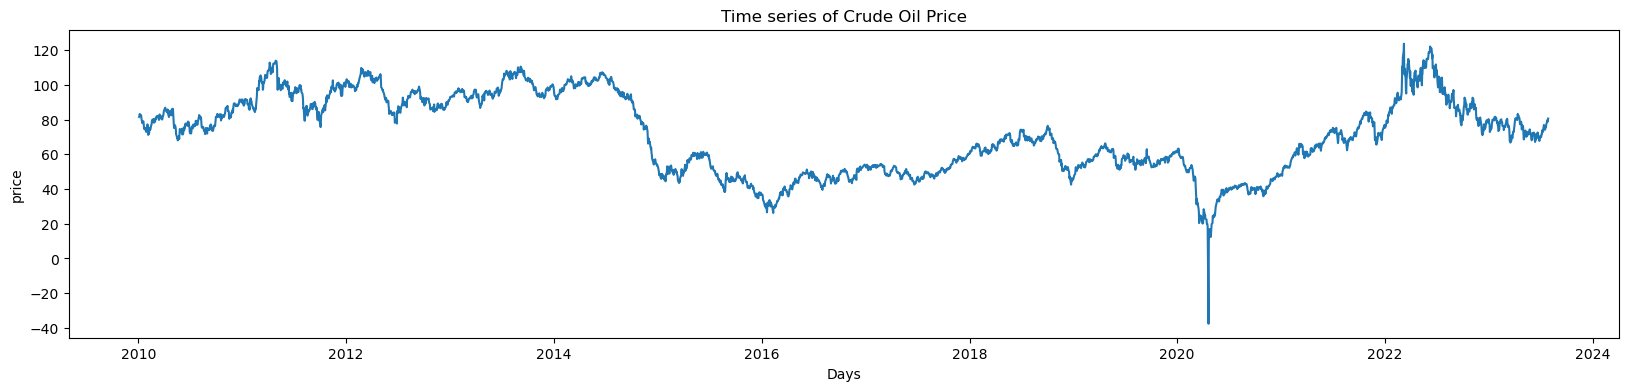

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
# Create plot
fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(df)
plt.title("Time series of Crude Oil Price")
plt.xlabel("Days")
plt.ylabel("price")

## LSTM models

2023-08-15 01:18:17.406226: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-08-15 01:18:17.510676: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-08-15 01:18:17.510688: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2023-08-15 01:18:17.981767: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2023-

Epoch 1/40


2023-08-15 01:18:18.573553: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2023-08-15 01:18:18.573567: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2023-08-15 01:18:18.573579: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (zesus): /proc/driver/nvidia/version does not exist
2023-08-15 01:18:18.573740: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


80/80 - 2s - loss: 0.0230 - 2s/epoch - 22ms/step
Epoch 2/40
80/80 - 0s - loss: 6.6485e-04 - 441ms/epoch - 6ms/step
Epoch 3/40
80/80 - 0s - loss: 3.8790e-04 - 412ms/epoch - 5ms/step
Epoch 4/40
80/80 - 0s - loss: 3.1906e-04 - 453ms/epoch - 6ms/step
Epoch 5/40
80/80 - 0s - loss: 3.1453e-04 - 421ms/epoch - 5ms/step
Epoch 6/40
80/80 - 0s - loss: 3.1252e-04 - 438ms/epoch - 5ms/step
Epoch 7/40
80/80 - 0s - loss: 3.1990e-04 - 424ms/epoch - 5ms/step
Epoch 8/40
80/80 - 0s - loss: 2.8023e-04 - 399ms/epoch - 5ms/step
Epoch 9/40
80/80 - 0s - loss: 2.7614e-04 - 421ms/epoch - 5ms/step
Epoch 10/40
80/80 - 0s - loss: 2.7713e-04 - 417ms/epoch - 5ms/step
Epoch 11/40
80/80 - 0s - loss: 2.6918e-04 - 413ms/epoch - 5ms/step
Epoch 12/40
80/80 - 0s - loss: 2.5569e-04 - 409ms/epoch - 5ms/step
Epoch 13/40
80/80 - 0s - loss: 2.7257e-04 - 407ms/epoch - 5ms/step
Epoch 14/40
80/80 - 0s - loss: 2.5816e-04 - 412ms/epoch - 5ms/step
Epoch 15/40
80/80 - 0s - loss: 2.4767e-04 - 410ms/epoch - 5ms/step
Epoch 16/40
80/80 - 0

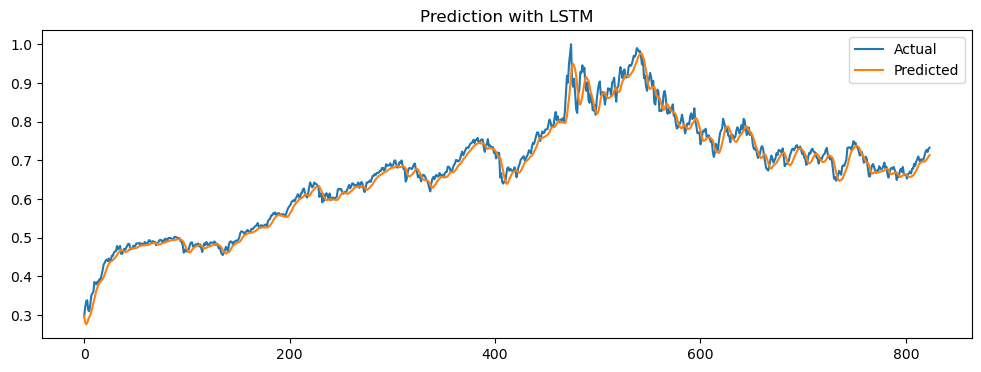

Computation time: 18.76 seconds


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error
import time

def create_lstm_dataset(dataset, time_steps=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_steps):
        dataX.append(dataset[i : i + time_steps])
        dataY.append(dataset[i + time_steps])
    return np.array(dataX), np.array(dataY)

def calculate_metrics(testY, predictions):
    mae = mean_absolute_error(testY, predictions)
    rmse = np.sqrt(mean_squared_error(testY, predictions))
    mask = testY != 0
    mape = np.mean(np.abs((testY[mask] - predictions[mask]) / testY[mask])) * 100
    mse = mean_squared_error(testY, predictions)
    rmse1 = np.sqrt(mse)
    nrmse_mean = rmse1 / np.mean(testY)
    nrmse_maxmin = rmse1 / (np.max(testY) - np.min(testY))
    return mae, rmse, mape, mse, rmse1, nrmse_mean, nrmse_maxmin

start_time = time.time()

# Load data from CSV
#df = pd.read_csv('your_dataset.csv')  # Replace 'your_dataset.csv' with your file name
df=df

# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df.values)

# Split data into training and testing sets
train_size = int(len(scaled_data) * 0.75)
train_data, test_data = scaled_data[:train_size], scaled_data[train_size:]

time_steps = 30

# Prepare training data
trainX, trainY = create_lstm_dataset(train_data, time_steps)
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))

# Define and train LSTM model
model = Sequential([
    LSTM(50, input_shape=(time_steps, 1)),
    Dense(1)
])
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=40, batch_size=32, verbose=2)

# Prepare testing data and make predictions
testX, testY = create_lstm_dataset(test_data, time_steps)
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))
predictions = model.predict(testX)

# Calculate metrics
mae, rmse, mape, mse, rmse1, nrmse_mean, nrmse_maxmin = calculate_metrics(testY, predictions)

# Print metrics
print("Mean Squared Error (MSE): {:.4e}".format(mse))
print("Root Mean Squared Error (RMSE1): {:.4e}".format(rmse1))
print("Normalized RMSE (based on mean): {:.4e}".format(nrmse_mean))
print("Normalized RMSE (based on max - min): {:.4e}".format(nrmse_maxmin))
print("Mean Absolute Error (MAE): {:.4f}".format(mae))
print("Root Mean Squared Error (RMSE): {:.4f}".format(rmse))
print("Mean Absolute Percentage Error (MAPE): {:.4f}%".format(mape))

# Plot results
plt.figure(figsize=(12, 4))
plt.plot(testY)
plt.plot(predictions)
plt.legend(['Actual', 'Predicted'])
plt.title("Prediction with LSTM")
plt.show()

end_time = time.time()
print("Computation time: {:.2f} seconds".format(end_time - start_time))


## Reservoir computing

Data dimensions (3413, 1)
max: 123.6999969482422 min: -37.630001068115234
mean: 71.43170232490608 std: 22.286415184471373


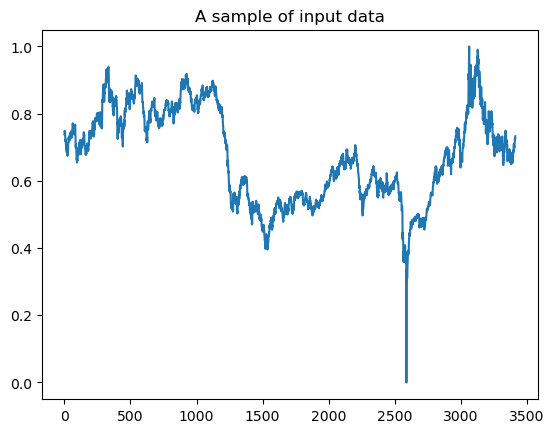

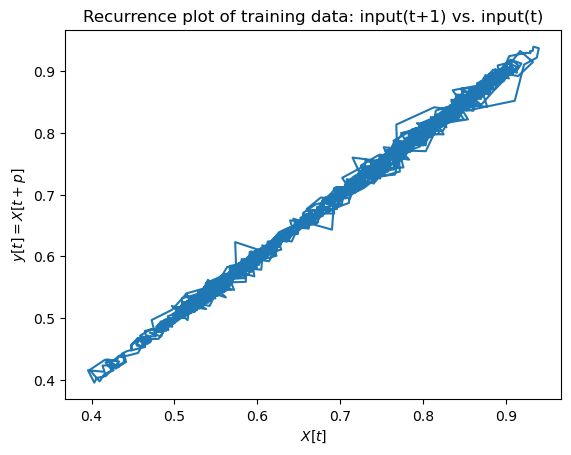

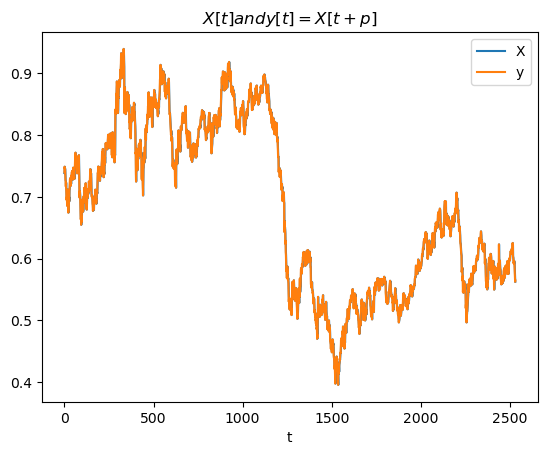

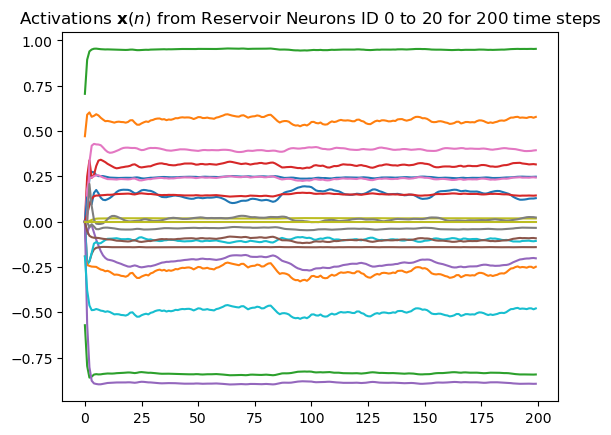

Mean Absolute Error (MAE): 0.0101
Root Mean Squared Error (RMSE): 0.0215
Mean Absolute Percentage Error (MAPE): 1.5739%
R-squared: 0.9788

********************
Errors computed over 840 time steps

Mean Squared error (MSE):	4.6191e-04
Root Mean Squared error (RMSE):	2.1492e-02
Normalized RMSE (based on mean):	3.2696e-02
Normalized RMSE (based on max - min):	2.1492e-02
********************


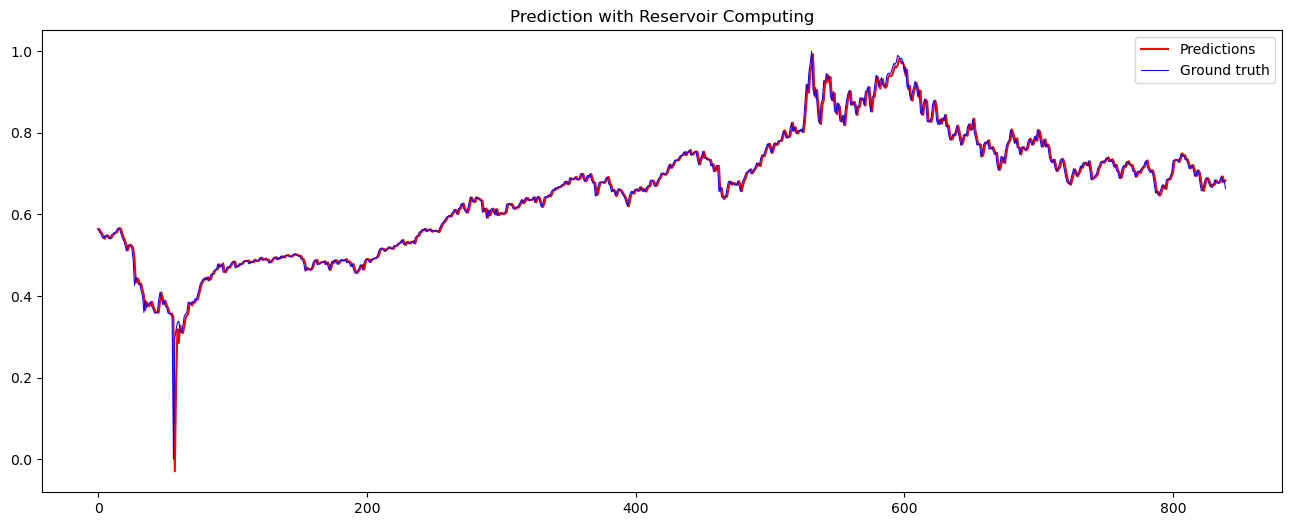

Computation time: 1.13 seconds


In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.observables import mse, nrmse, rmse
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

def normalize_data(data):
    return (data - data.min()) / (data.max() - data.min())

def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    mse_score = mse(y_true, y_pred)
    rmse_score = rmse_val  # Change the variable name here
    nmrse_mean = nrmse(y_true, y_pred, norm_value=y_true.mean())
    nmrse_maxmin = nrmse(y_true, y_pred, norm_value=y_true.max() - y_true.min())
    r2 = r2_score(y_true, y_pred)
    return mae, rmse_score, mape, mse_score, rmse_score, nmrse_mean, nmrse_maxmin, r2


start_time = time.time()

# Load data from CSV
#df = pd.read_csv('your_dataset.csv')  # Replace 'your_dataset.csv' with your file name
df=df
Dat = np.array(df)

# Set constants
SEED = 42
VERBOSE = True
units = 10000
horizon = 1

if __name__ == "__main__":
    rpy.set_seed(SEED)
    rpy.verbosity(0)

    if VERBOSE:
        print("Data dimensions", Dat.shape)
        print("max:", Dat.max(), "min:", Dat.min())
        print("mean:", Dat.mean(), "std:", Dat.std())

    data = normalize_data(Dat)

    plt.figure()
    plt.plot(data)
    plt.title("A sample of input data")
    plt.show()

    train_size = 2531
    test_size = 840

    X = data[:train_size]
    y = data[horizon : train_size + horizon]
    X_test = data[train_size : train_size + test_size]
    y_test = data[train_size + horizon : train_size + test_size + horizon]

    plt.figure()
    plt.plot(X, y)
    plt.xlabel("$X[t]$")
    plt.ylabel("$y[t]=X[t+p]$")
    plt.title("Recurrence plot of training data: input(t+1) vs. input(t)")
    plt.show()

    plt.figure()
    plt.plot(X, label="X")
    plt.plot(y, label="y")
    plt.xlabel("t")
    plt.legend()
    plt.title("$X[t] and y[t]=X[t+p]$")
    plt.show()

    # Reservoir parameters
    units = 20
    leak_rate = 0.75
    rho = 1.025
    input_scaling = 1.0
    rc_connectivity = 0.15
    input_connectivity = 0.2
    fb_connectivity = 1.1
    regularization_coef = 1e-8
    warmup = 100
    feedback = False

    rng = np.random.default_rng(SEED)
    W = rng.random((units, units)) - 0.5
    input_bias = True  # Set to True or False depending on your choice
    Win = rng.random((units, 1 + int(input_bias))) - 0.5
    Wfb = rng.random((units, 1)) - 0.5

    mask = rng.random((units, units))
    W[mask > rc_connectivity] = 0

    mask = rng.random((units, Win.shape[1]))
    Win[mask > input_connectivity] = 0

    mask = rng.random((units, Wfb.shape[1]))
    Wfb[mask > fb_connectivity] = 0

    Win = Win * input_scaling

    # Calculate the spectral radius
    original_spectral_radius = np.max(np.abs(np.linalg.eigvals(W)))

    # Rescale the matrix to reach the requested spectral radius:
    W = W * (rho / original_spectral_radius)

    # Create a reservoir
    reservoir = Reservoir(
        units,
        lr=leak_rate,
        sr=rho,
        input_bias=input_bias,
        input_scaling=input_scaling,
        rc_connectivity=rc_connectivity,
        input_connectivity=input_connectivity,
        fb_connectivity=fb_connectivity,
        name="reservoir",
    )

    readout = Ridge(ridge=regularization_coef, name="readout")

    if feedback:
        reservoir = reservoir << readout

    esn = reservoir >> readout

    internal_trained = reservoir.run(X)

    reservoir.reset()

    plt.figure()
    plt.plot(internal_trained[:200, :21])
    plt.title("Activations $\\mathbf{x}(n)$ from Reservoir Neurons ID 0 to 20 for 200 time steps")
    plt.show()

    esn = esn.fit(X, y, warmup=warmup)

    y_pred = esn.run(X_test)

    mae, rmse, mape, mse_score, rmse_score, nmrse_mean, nmrse_maxmin, r2 = calculate_metrics(y_test, y_pred)

    print("Mean Absolute Error (MAE): {:.4f}".format(mae))
    print("Root Mean Squared Error (RMSE): {:.4f}".format(rmse))
    print("Mean Absolute Percentage Error (MAPE): {:.4f}%".format(mape))
    print("R-squared: {:.4f}".format(r2))
    print("\n********************")
    print(f"Errors computed over {test_size} time steps")
    print("\nMean Squared error (MSE):\t%.4e" % mse_score)
    print("Root Mean Squared error (RMSE):\t%.4e" % rmse_score)
    print("Normalized RMSE (based on mean):\t%.4e" % nmrse_mean)
    print("Normalized RMSE (based on max - min):\t%.4e" % nmrse_maxmin)
    print("********************")

    plt.figure(figsize=(16, 6))
    plt.plot(y_pred, color="red", lw=1.5, label="Predictions")
    plt.plot(y_test, color="blue", lw=0.75, label="Ground truth")
    plt.title("Prediction with Reservoir Computing")
    plt.legend()
    plt.show()

end_time = time.time()
print("Computation time: {:.2f} seconds".format(end_time - start_time))


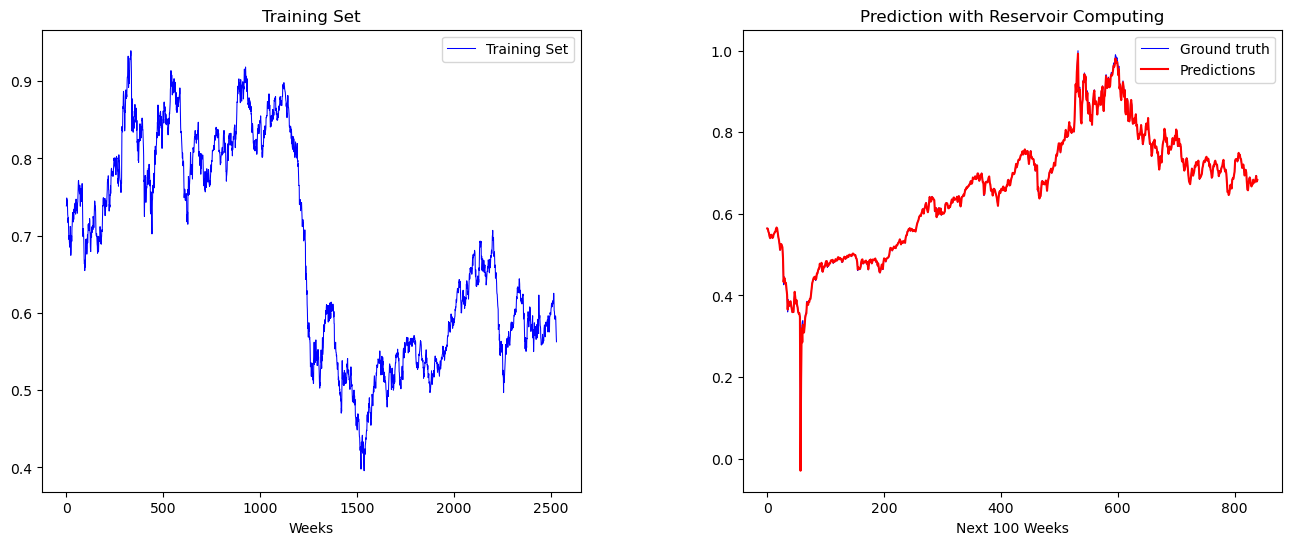

In [8]:
import matplotlib.pyplot as plt


# create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# plot training set on the left subplot
ax1.plot(X, color='blue', lw=0.75, label='Training Set')
ax1.set_xlabel('Weeks')
ax1.set_title('Training Set')
ax1.legend()

# plot testing set and predicted values on the right subplot
ax2.plot(X_test, color='blue', lw=0.75, label='Ground truth')
ax2.plot(y_pred, color='red', lw=1.5, label='Predictions')
ax2.set_xlabel('Next 100 Weeks')

ax2.set_title('Prediction with Reservoir Computing')
ax2.legend()

# adjust the spacing between subplots
plt.subplots_adjust(wspace=0.3)

# show plot
plt.show()

Text(0.5, 1.0, 'Prediction with Reservoir Computing')

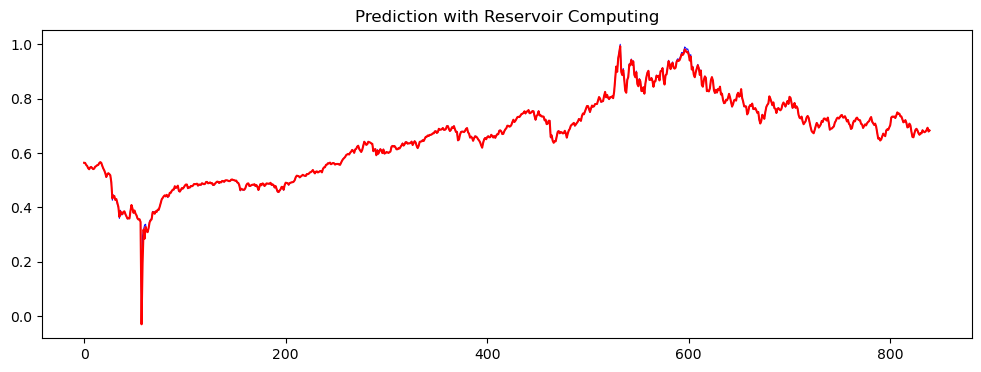

In [9]:
# Plot results
plt.figure(figsize=(12, 4))
# plot testing set and predicted values on the right subplot
plt.plot(X_test, color='blue', lw=0.75, label='Ground truth')
plt.plot(y_pred, color='red', lw=1.5, label='Predictions')
plt.title('Prediction with Reservoir Computing')

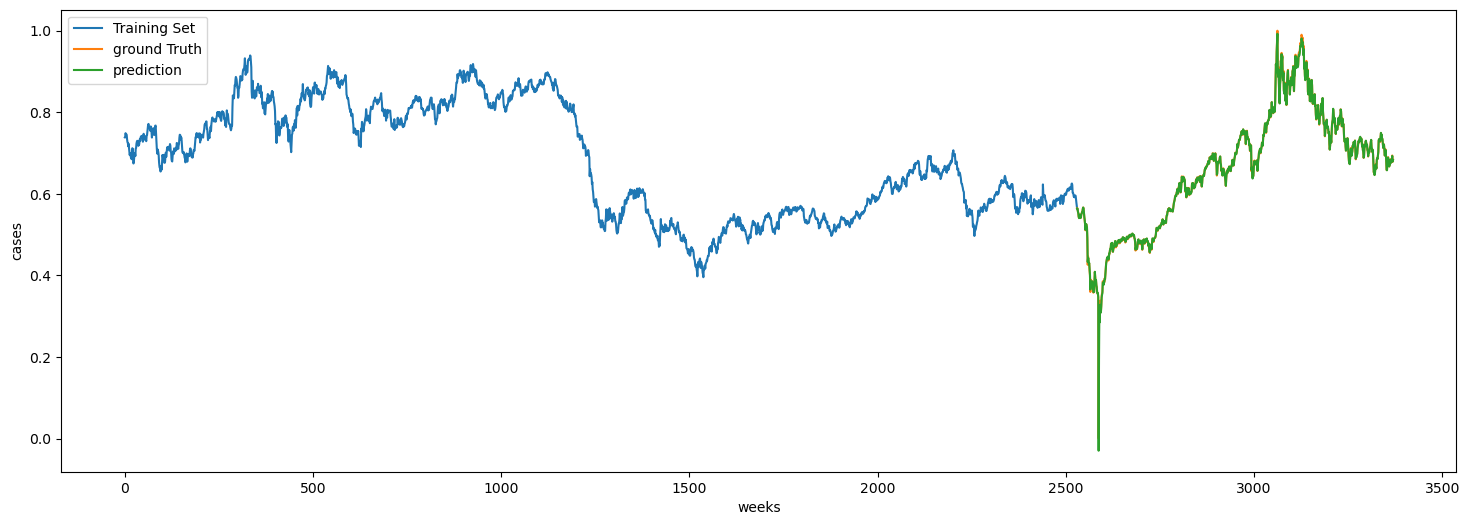

In [10]:
y_future = esn.run(y_pred)
t1=np.arange(0,len(X))
t2=np.arange(len(X)-1,len(X)+839)

# Create plot
fig, ax = plt.subplots(figsize=(18, 6))

# Plot time series 1
ax.plot(t1, X, label='Training Set')

# Plot time series 2
ax.plot(t2, X_test, label='ground Truth')

# Plot time series 2
ax.plot(t2, y_pred, label='prediction')

# Add labels and legend
ax.set_xlabel('weeks')
ax.set_ylabel('cases')
ax.legend()

# Show plot
plt.show()